<a href="https://colab.research.google.com/github/KyeongTaekOh/health-checkup-analysis/blob/main/notebook/analysis_ver02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 종합 실습 — 건강검진 데이터 분석 (재현 가능한 노트북)

### 문제 확인
이 노트북은 **위에서 아래로 한 번에 실행**되도록 구성되어 있습니다.
상단에 환경 설정(설치 · import · 경로 · 난수 고정)을 모아 두고,
그 다음 STEP 0~5 분석이 순서대로 이어집니다.

> 처음 실행 시: `런타임 > 모두 실행` (Ctrl+F9)


---
## 0. 환경 설정 (Setup)

재현성을 위해 **설치 → import → 경로 → 난수 고정**을 노트북 맨 위에 모읍니다.


In [1]:
# [설치] 필요한 패키지를 첫 코드 셀에서 한 번에 설치
#  - Colab 기본 제공 외 패키지를 여기서 설치해야 새 런타임에서도 재현됩니다.
!pip install -q scikit-posthocs openpyxl

In [2]:
# [import] 사용하는 라이브러리를 한 셀에 모읍니다
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import scikit_posthocs as sp
from sklearn.metrics import roc_auc_score, roc_curve

In [3]:
# [한글 폰트] 그래프에 한글이 깨지지 않도록 설정 (Colab)
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)
sns.set_theme(style='whitegrid', palette='colorblind', font='NanumGothic')

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [12]:
# [경로] 데이터 경로는 코드 곳곳에 직접 쓰지 말고 변수로 관리합니다
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/강의자료/스마트헬스케어협회/바이오전문인력양성사업/데이터 분석환경 구축 및 협업 실습'
DATA_PATH = f'{BASE_DIR}/DATA/건강검진_실습데이터.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# [난수 고정] 실행할 때마다 결과가 달라지지 않도록 seed 고정
SEED = 42
np.random.seed(SEED)

In [10]:
# [변수 정의] 분석 전반에서 사용할 변수 목록을 한곳에 정의
num_cols = ['age', 'bmi', 'waist', 'sbp', 'glucose', 'tg', 'hdl', 'crp']
cat_cols = ['sex', 'region', 'smoking', 'exercise_freq', 'metabolic_syndrome']

---
## STEP 0. 데이터 불러오기


In [13]:
# 데이터 로드 (경로 변수 사용)
df = pd.read_excel(DATA_PATH)
df_raw = df.copy()          # 진단·비교용 원본 보존
df.head()

,id,age,sex,region,smoking,exercise_freq,bmi,waist,sbp,glucose,tg,hdl,crp,metabolic_syndrome
0,1,66,남,충청,흡연,0,25.9,118.9,150,116,46,34.0,2.65,1
1,2,41,여,호남,비흡연,2,26.8,108.3,129,109,70,60.0,0.48,0
2,3,46,남,영남,흡연,0,27.6,112.6,144,113,79,48.0,0.66,0
3,4,35,남,영남,비흡연,0,26.2,108.1,134,109,46,50.0,1.44,0
4,5,60,여,호남,흡연,3,22.3,99.5,149,125,98,55.0,0.30,1


---
## STEP 1. 데이터 진단 — 구조 · 타입 · 결측


In [14]:
# 구조 · 타입 · 결측 확인
print(df.shape)
df.info()

(400, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  400 non-null    int64  
 1   age                 400 non-null    int64  
 2   sex                 400 non-null    object 
 3   region              400 non-null    object 
 4   smoking             400 non-null    object 
 5   exercise_freq       400 non-null    int64  
 6   bmi                 400 non-null    float64
 7   waist               400 non-null    float64
 8   sbp                 400 non-null    int64  
 9   glucose             400 non-null    int64  
 10  tg                  400 non-null    int64  
 11  hdl                 394 non-null    float64
 12  crp                 388 non-null    float64
 13  metabolic_syndrome  400 non-null    int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 43.9+ KB


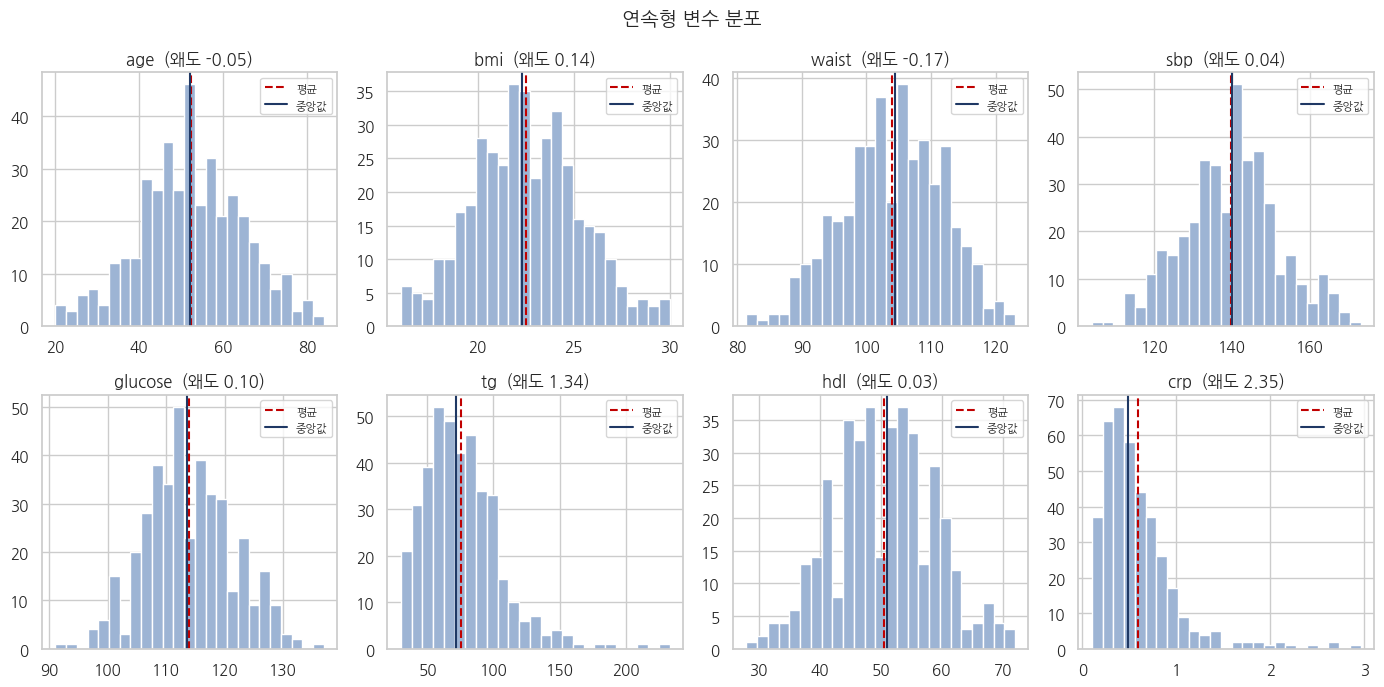

In [15]:
# 연속형 변수 전체 분포 — 히스토그램 + 평균/중앙값 + 왜도
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df[c].dropna(), bins=25, color='#9DB4D4', edgecolor='white')
    ax.axvline(df[c].mean(),   color='#C00000', ls='--', label='평균')
    ax.axvline(df[c].median(), color='#1F3864', ls='-',  label='중앙값')
    ax.set_title(f"{c}  (왜도 {df[c].skew():.2f})")
    ax.legend(fontsize=8)
plt.suptitle('연속형 변수 분포', fontsize=14)
plt.tight_layout(); plt.show()

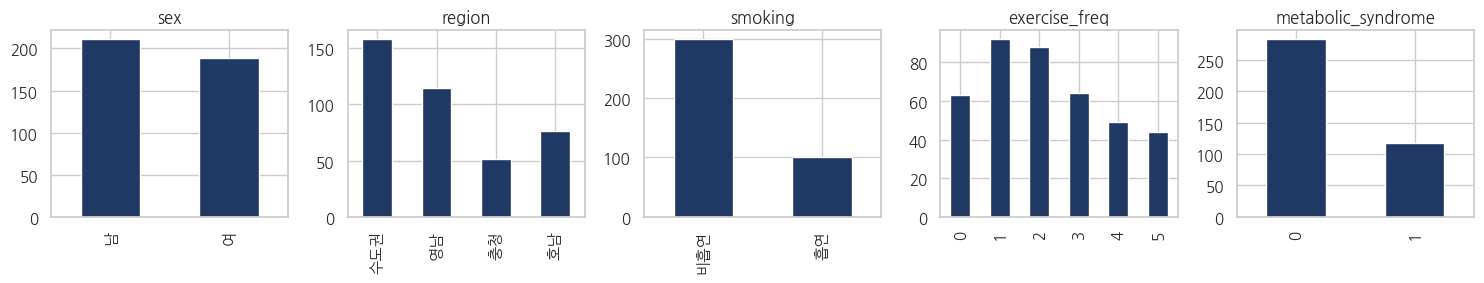

In [16]:
# 범주형 변수 전체 분포 — 막대그래프
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, c in zip(axes, cat_cols):
    df[c].value_counts().sort_index().plot(kind='bar', ax=ax, color='#1F3864')
    ax.set_title(c); ax.set_xlabel('')
plt.tight_layout(); plt.show()

In [17]:
# 결측 비율 확인 (대치 전 원본 기준)
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(1)
pd.DataFrame({'결측수': miss, '결측%': miss_pct})[miss > 0]

,결측수,결측%
hdl,6,1.5
crp,12,3.0


In [18]:
# 결측 대치 — 중앙값으로 통일
for c in ['hdl', 'crp']:
    df[c] = df[c].fillna(df[c].median())

print('결측 합계:', df.isnull().sum().sum())

결측 합계: 0


---
## STEP 2. 기술통계 — 중심 · 산포 · 분포 요약


In [19]:
# 연속형 변수 요약 — 중심(평균·중앙값) · 산포(표준편차) · 분포(왜도)
desc = df[num_cols].agg(['mean', 'median', 'std']).T
desc['skew'] = df[num_cols].skew()
desc.round(2)

,mean,median,std,skew
age,52.28,52.00,12.41,-0.05
bmi,22.52,22.30,2.81,0.14
waist,103.97,104.35,7.81,-0.17
sbp,139.76,140.00,12.15,0.04
glucose,113.95,113.50,7.54,0.10
tg,75.84,72.00,28.92,1.34
hdl,50.49,51.00,8.17,0.03
crp,0.58,0.48,0.41,2.40


In [20]:
# 산포 비교를 위한 변동계수(CV) — 단위가 다른 변수 간 상대적 퍼짐
desc['CV(%)'] = (df[num_cols].std() / df[num_cols].mean() * 100).round(1)
desc.round(2)

,mean,median,std,skew,CV(%)
age,52.28,52.00,12.41,-0.05,23.7
bmi,22.52,22.30,2.81,0.14,12.5
waist,103.97,104.35,7.81,-0.17,7.5
sbp,139.76,140.00,12.15,0.04,8.7
glucose,113.95,113.50,7.54,0.10,6.6
tg,75.84,72.00,28.92,1.34,38.1
hdl,50.49,51.00,8.17,0.03,16.2
crp,0.58,0.48,0.41,2.40,69.7


In [21]:
# 범주형 변수 빈도 — 개수와 비율(%)
for c in cat_cols:
    counts = df[c].value_counts().sort_index()
    pct = (counts / len(df) * 100).round(1)
    print(f'── {c} ──')
    print(pd.DataFrame({'개수': counts, '비율(%)': pct}))
    print()

── sex ──
      개수  비율(%)
sex            
남    211   52.8
여    189   47.2

── region ──
         개수  비율(%)
region            
수도권     158   39.5
영남      115   28.7
충청       51   12.8
호남       76   19.0

── smoking ──
          개수  비율(%)
smoking            
비흡연      299   74.8
흡연       101   25.2

── exercise_freq ──
               개수  비율(%)
exercise_freq           
0              63   15.8
1              92   23.0
2              88   22.0
3              64   16.0
4              49   12.2
5              44   11.0

── metabolic_syndrome ──
                     개수  비율(%)
metabolic_syndrome            
0                   283   70.8
1                   117   29.2



---
## STEP 3. 연속형 검정 — 집단 간 평균 차이


In [22]:
# 그룹별 박스플롯 — 연속형 8개를 한 화면에
def plot_box(group_col):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, y in zip(axes.ravel(), num_cols):
        sns.boxplot(data=df, x=group_col, y=y,
                    hue=group_col, palette='colorblind', legend=False, ax=ax)
        ax.set_title(y); ax.set_xlabel('')
    plt.suptitle(f'그룹: {group_col}', fontsize=14)
    plt.tight_layout(); plt.show()

In [23]:
# 2집단 비교 — 정규성·등분산 점검 후 검정 자동 선택
def run_2group(group_col):
    a, b = sorted(df[group_col].dropna().unique())
    rows = []
    for y in num_cols:
        g1 = df[df[group_col] == a][y].dropna()
        g2 = df[df[group_col] == b][y].dropna()

        normal = (stats.shapiro(g1).pvalue > 0.05) and (stats.shapiro(g2).pvalue > 0.05)
        equal_var = stats.levene(g1, g2).pvalue > 0.05

        if not normal:
            stat, p = stats.mannwhitneyu(g1, g2)
            method = 'Mann-Whitney'
        elif equal_var:
            stat, p = stats.ttest_ind(g1, g2, equal_var=True)
            method = 'Student t'
        else:
            stat, p = stats.ttest_ind(g1, g2, equal_var=False)
            method = 'Welch t'

        d = (g1.mean() - g2.mean()) / df[y].std()
        rows.append([y, method, round(stat, 2), round(p, 4), round(d, 2)])

    out = pd.DataFrame(rows, columns=['변수', '검정', '통계량', 'p', 'Cohen_d'])
    out['유의'] = np.where(out['p'] < 0.05, '*', '')
    return out.sort_values('p')

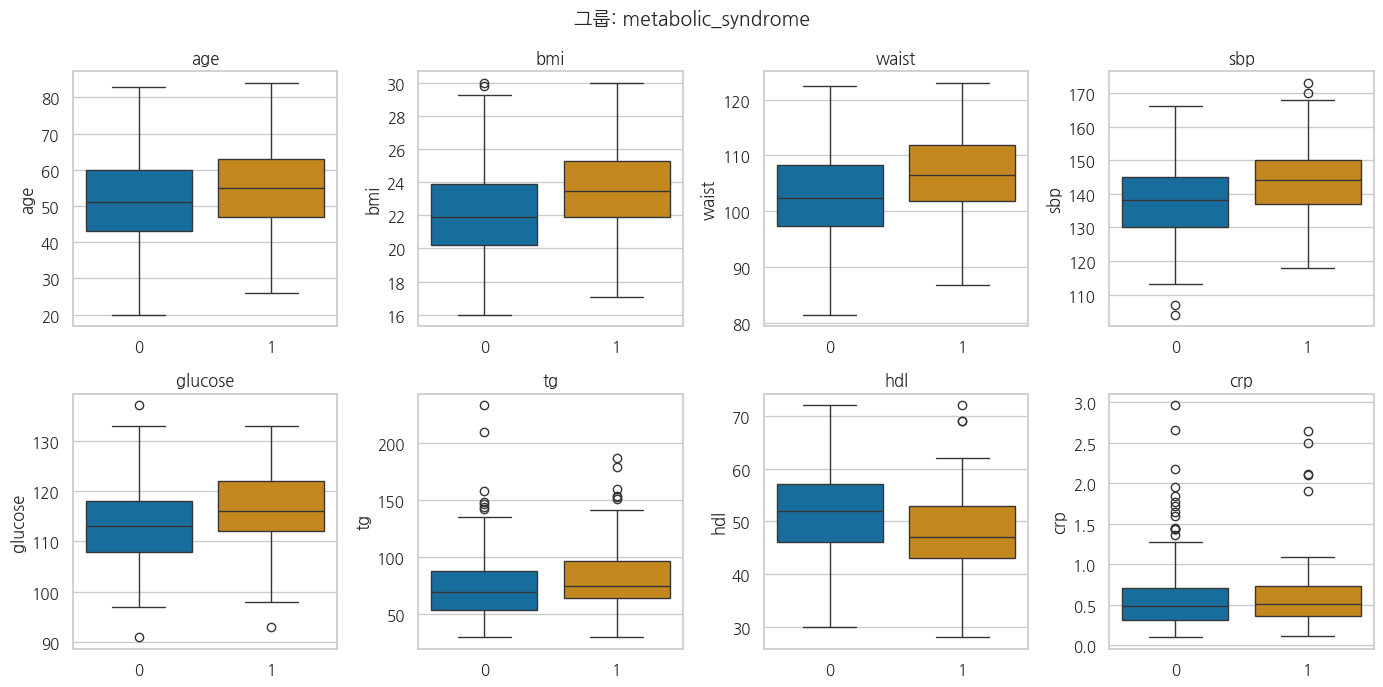

,변수,검정,통계량,p,Cohen_d,유의
1,bmi,Student t,-4.96,0.0000,-0.53,*
2,waist,Student t,-5.17,0.0000,-0.55,*
3,sbp,Student t,-5.53,0.0000,-0.59,*
6,hdl,Student t,4.26,0.0000,0.46,*
4,glucose,Student t,-3.28,0.0011,-0.36,*
0,age,Student t,-2.74,0.0064,-0.30,*
5,tg,Mann-Whitney,13702.00,0.0067,-0.29,*
7,crp,Mann-Whitney,15512.00,0.3214,-0.08,


In [24]:
# 그룹: metabolic_syndrome
plot_box('metabolic_syndrome')
run_2group('metabolic_syndrome')

In [25]:
# 3집단 이상 비교 — 가정 점검 후 검정 자동 선택
def run_multigroup(group_col):
    rows = []
    for y in num_cols:
        groups = [g[y].dropna().values for _, g in df.groupby(group_col)]

        normal = all(stats.shapiro(g).pvalue > 0.05 for g in groups)
        equal_var = stats.levene(*groups).pvalue > 0.05

        if not normal:
            stat, p = stats.kruskal(*groups)
            method = 'Kruskal'
        elif equal_var:
            stat, p = stats.f_oneway(*groups)
            method = 'ANOVA'
        else:
            res = stats.alexandergovern(*groups)
            stat, p = res.statistic, res.pvalue
            method = 'Welch ANOVA'

        all_vals = np.concatenate(groups)
        ss_between = sum(len(g) * (g.mean() - all_vals.mean())**2 for g in groups)
        ss_total = ((all_vals - all_vals.mean())**2).sum()
        eta2 = ss_between / ss_total

        rows.append([y, method, round(stat, 2), round(p, 4), round(eta2, 3)])

    out = pd.DataFrame(rows, columns=['변수', '검정', '통계량', 'p', 'eta2'])
    out['유의'] = np.where(out['p'] < 0.05, '*', '')
    return out.sort_values('p')

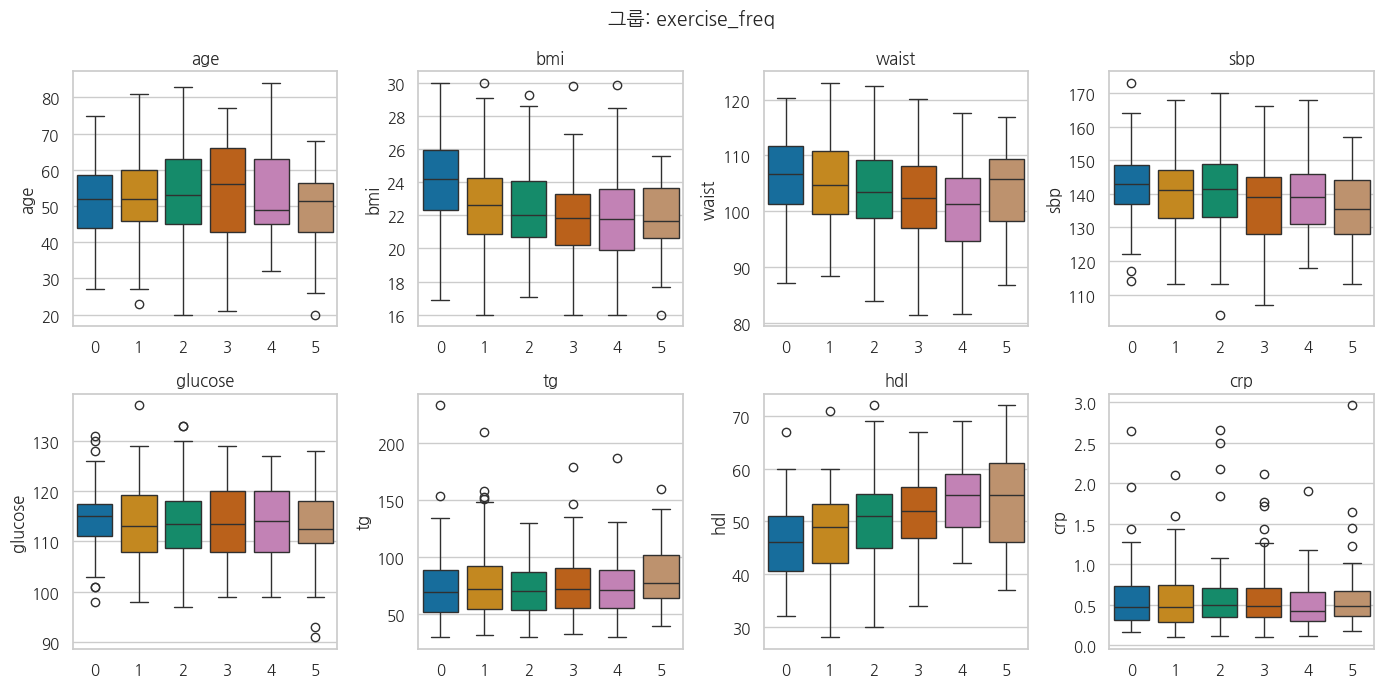

,변수,검정,통계량,p,eta2,유의
6,hdl,ANOVA,10.56,0.0000,0.118,*
1,bmi,ANOVA,5.21,0.0001,0.062,*
2,waist,ANOVA,3.45,0.0046,0.042,*
3,sbp,ANOVA,2.93,0.0131,0.036,*
5,tg,Kruskal,6.87,0.2306,0.019,
0,age,Kruskal,3.88,0.5674,0.011,
4,glucose,ANOVA,0.59,0.7095,0.007,
7,crp,Kruskal,1.64,0.8967,0.004,


In [26]:
# 그룹: exercise_freq
plot_box('exercise_freq')
run_multigroup('exercise_freq')

In [27]:
# 사후검정 — 유의한 조합에서 '어느 그룹 쌍이 다른가'
#   정규(ANOVA 계열) → Tukey HSD,  비정규(Kruskal) → Dunn
def posthoc(group_col, y, method):
    print(f'[{group_col} × {y}]  ({method})')
    sub = df[[group_col, y]].dropna()
    if method == 'Kruskal':
        display(sp.posthoc_dunn(sub, val_col=y, group_col=group_col,
                                p_adjust='bonferroni').round(3))
    else:
        res = pairwise_tukeyhsd(sub[y], sub[group_col])
        print(res)

In [28]:
# 예시: exercise_freq × hdl
posthoc('exercise_freq', 'hdl', 'ANOVA')

[exercise_freq × hdl]  (ANOVA)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   2.1832 0.5138 -1.4344  5.8009  False
     0      2   4.6185 0.0044  0.9676  8.2694   True
     0      3   5.7009 0.0006  1.7748   9.627   True
     0      4   8.2041    0.0  3.9904 12.4178   True
     0      5   8.2662    0.0    3.92 12.6125   True
     1      2   2.4353  0.282 -0.8633  5.7338  False
     1      3   3.5177 0.0599 -0.0831  7.1185  False
     1      4   6.0209 0.0002  2.1085  9.9332   True
     1      5    6.083 0.0003  2.0282 10.1378   True
     2      3   1.0824 0.9572 -2.5518  4.7166  False
     2      4   3.5856 0.0986 -0.3576  7.5287  False
     2      5   3.6477 0.1104 -0.4368  7.7323  False
     3      4   2.5032 0.5279 -1.6961  6.7025  False
     3      5   2.5653 0.5354 -1.7669  6.8976  False
     4      5   0.0622    1.0 -4.5324  4.6567  False
---------------

---
## STEP 4. 범주형 검정 — 범주 간 관련성


In [29]:
# 범주형 일괄 검정 — 여러 변수 × 대사증후군
#   기대빈도 점검 → 카이제곱 / Fisher 자동 선택 + 효과크기(Cramér's V)
def run_chi2(target='metabolic_syndrome'):
    cat_vars = ['sex', 'region', 'smoking', 'exercise_freq']
    rows = []
    for c in cat_vars:
        ct = pd.crosstab(df[c], df[target])
        chi2, p, dof, expected = stats.chi2_contingency(ct)
        min_exp = expected.min()

        if (expected < 5).any() and ct.shape == (2, 2):
            _, p = stats.fisher_exact(ct)
            method = 'Fisher'
        else:
            method = 'Chi2'

        n = ct.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
        rows.append([c, method, round(chi2, 2), dof,
                     round(p, 4), round(cramers_v, 3), round(min_exp, 1)])

    out = pd.DataFrame(rows, columns=['변수', '검정', 'chi2', 'dof',
                                      'p', 'CramersV', '최소기대빈도'])
    out['유의'] = np.where(out['p'] < 0.05, '*', '')
    return out.sort_values('p')

run_chi2('metabolic_syndrome')

,변수,검정,chi2,dof,p,CramersV,최소기대빈도,유의
2,smoking,Chi2,18.41,1,0.0000,0.215,29.5,*
0,sex,Chi2,7.92,1,0.0049,0.141,55.3,*
1,region,Chi2,3.69,3,0.2965,0.096,14.9,
3,exercise_freq,Chi2,3.52,5,0.6210,0.094,12.9,


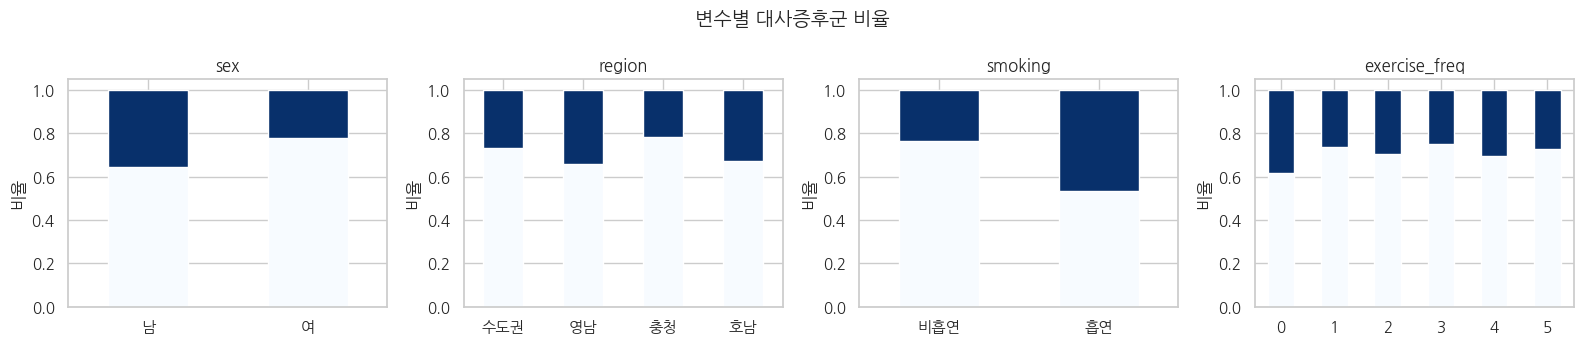

In [30]:
# 교차표 시각화 일괄 — 각 변수별 대사증후군 비율
def plot_crosstab(target='metabolic_syndrome'):
    cat_vars = ['sex', 'region', 'smoking', 'exercise_freq']
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    for ax, c in zip(axes, cat_vars):
        (pd.crosstab(df[c], df[target], normalize='index')
           .plot(kind='bar', stacked=True, colormap='Blues',
                 ax=ax, legend=False))
        ax.set_title(c); ax.set_xlabel(''); ax.set_ylabel('비율')
        ax.tick_params(axis='x', rotation=0)
    plt.suptitle('변수별 대사증후군 비율', fontsize=14)
    plt.tight_layout(); plt.show()

plot_crosstab('metabolic_syndrome')

---
## STEP 5. 상관 · 회귀 — 관계와 독립적 효과


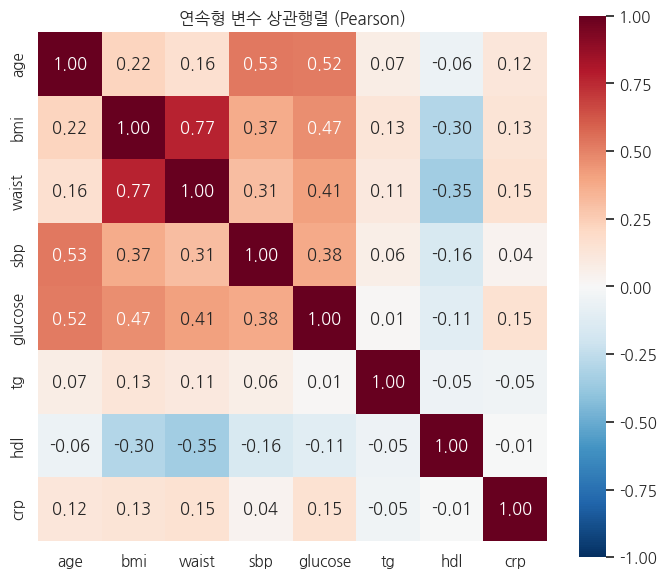

In [31]:
# 상관행렬 — 연속형 변수 간 선형 관계
corr = df[num_cols].corr(method='pearson')

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('연속형 변수 상관행렬 (Pearson)')
plt.tight_layout(); plt.show()

In [32]:
# 범주형 변수를 0/1 더미로 변환
df['male'] = (df['sex'] == '남').astype(int)
df['smk']  = (df['smoking'] == '흡연').astype(int)

# 다중공선성 점검 — VIF
predictors = ['age', 'bmi', 'waist', 'glucose', 'tg', 'hdl', 'crp', 'male', 'smk']
X = add_constant(df[predictors])

vif = pd.DataFrame({
    '변수': predictors,
    'VIF': [variance_inflation_factor(X.values, i + 1) for i in range(len(predictors))]
})
vif.sort_values('VIF', ascending=False).round(2)

,변수,VIF
2,waist,3.76
1,bmi,3.10
7,male,1.76
3,glucose,1.72
0,age,1.42
5,hdl,1.21
8,smk,1.11
4,tg,1.07
6,crp,1.06


In [33]:
# 로지스틱 회귀 — 모든 변수를 동시에 넣어 서로 보정
model = smf.logit(
    'metabolic_syndrome ~ age + bmi + waist + glucose + tg + hdl + crp + male + smk',
    data=df
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.533683
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     metabolic_syndrome   No. Observations:                  400
Model:                          Logit   Df Residuals:                      390
Method:                           MLE   Df Model:                            9
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.1170
Time:                        14:14:35   Log-Likelihood:                -213.47
converged:                       True   LL-Null:                       -241.75
Covariance Type:            nonrobust   LLR p-value:                 6.152e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.8868      2.735     -2.518      0.012     -12.247      -1.526
age            0.0127      0.

In [34]:
# 조정 오즈비(adjusted OR)와 95% 신뢰구간 — 해석용 표
res = pd.DataFrame({
    'OR': np.exp(model.params),
    'p': model.pvalues
}).join(np.exp(model.conf_int()).rename(columns={0: 'CI_low', 1: 'CI_high'}))
res['유의'] = np.where(res['p'] < 0.05, '*', '')
res.drop('Intercept').round(3).sort_values('p')

,OR,p,CI_low,CI_high,유의
smk,2.757,0.000,1.627,4.672,*
hdl,0.959,0.011,0.929,0.990,*
tg,1.005,0.217,0.997,1.013,
waist,1.035,0.256,0.976,1.097,
age,1.013,0.264,0.990,1.036,
bmi,1.077,0.314,0.932,1.245,
glucose,1.014,0.477,0.975,1.055,
crp,0.852,0.604,0.466,1.558,
male,0.872,0.661,0.473,1.608,


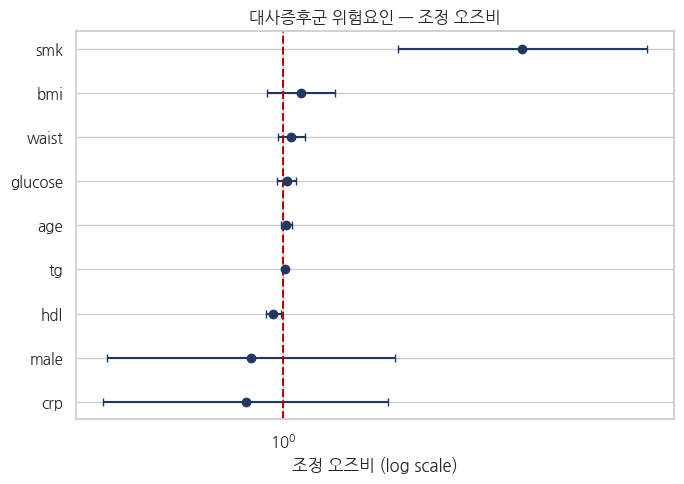

In [35]:
# 조정 오즈비 시각화 — forest plot
plot_df = res.drop('Intercept').sort_values('OR')
plt.figure(figsize=(7, 5))
plt.errorbar(plot_df['OR'], range(len(plot_df)),
             xerr=[plot_df['OR'] - plot_df['CI_low'],
                   plot_df['CI_high'] - plot_df['OR']],
             fmt='o', color='#1F3864', capsize=3)
plt.axvline(1, color='#C00000', ls='--')
plt.yticks(range(len(plot_df)), plot_df.index)
plt.xscale('log'); plt.xlabel('조정 오즈비 (log scale)')
plt.title('대사증후군 위험요인 — 조정 오즈비'); plt.tight_layout(); plt.show()

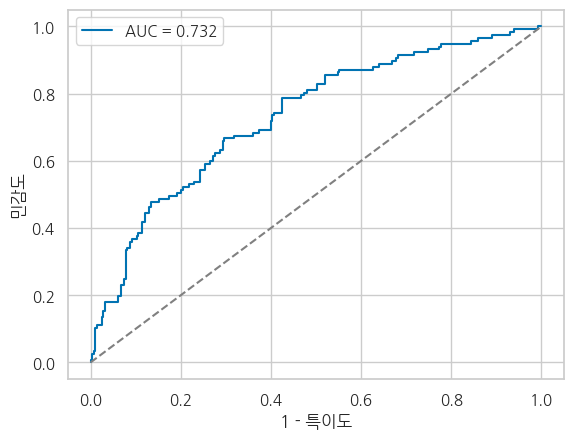

In [36]:
# ROC 곡선 / AUC
used = model.model.data.row_labels
y_true = df.loc[used, 'metabolic_syndrome']
pred = model.predict(df.loc[used])

auc = roc_auc_score(y_true, pred)
fpr, tpr, _ = roc_curve(y_true, pred)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('1 - 특이도'); plt.ylabel('민감도')
plt.legend()
plt.show()